In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Recruitment_master.csv')
print(df.shape)

(500, 49)


The Recruitment_master.csv loaded with 500 rows and 49 columns — the original 19 candidate columns + 24 placement columns + 6 engineered features you created in Phase 7. This confirms the clean file is intact.

<Axes: >

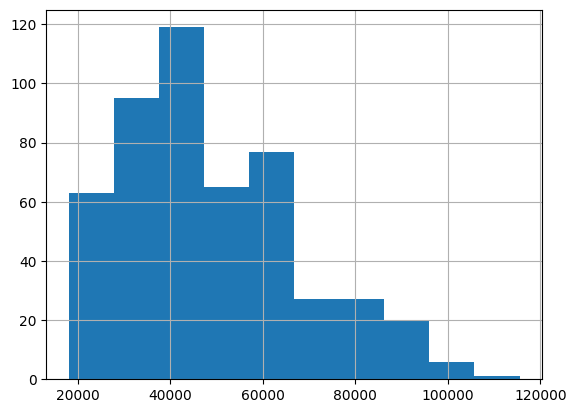

In [9]:
# ===== UNIVARIATE ANALYSIS ===== # distribution of individual columns

df['was_placed'].value_counts()           # placement rate
df['seniority_level'].value_counts()
df['expected_salary_gbp'].hist()

The histogram shows the distribution of expected_salary_gbp across all 500 candidates:

The largest group (~120 candidates) expects salaries in the £40,000–£50,000 range — this is the most competitive salary band

A second cluster (~100 candidates) sits around £30,000–£40,000

Salaries drop off steadily above £60,000, with very few candidates (~5) expecting over £100,000

The distribution is right-skewed — most candidates expect modest salaries, with a long tail of high earners

What this means: The dataset is dominated by mid-range salary expectations. High earners (£80k+) are rare and may be harder to place — worth investigating separately.

In [10]:
print(df['was_placed'].value_counts())
print(df.groupby('seniority_level')['was_placed'].mean().sort_values())
print(df.select_dtypes(include='number').corr()['was_placed'].sort_values())

was_placed
1    370
0    130
Name: count, dtype: int64
seniority_level
junior         0.692982
mid            0.733766
senior         0.735632
intern         0.756098
entry level    0.798077
Name: was_placed, dtype: float64
days_since_registration     -0.055178
english_proficiency         -0.032953
expected_salary_gbp         -0.018073
years_of_experience         -0.012325
candidate_id                 0.028752
assessment_score             0.054348
availability_notice_days     0.061824
time_to_hire_days            0.791113
offered_salary_gbp           0.793661
client_satisfaction_score    0.809607
interview_rounds             0.825886
salary_gap                   0.894659
salary_match_ratio           0.991650
was_placed                   1.000000
placement_id                      NaN
placement_fee_gbp                 NaN
estimated_fee_value_gbp           NaN
performance_rating                NaN
skills_count                      NaN
interview_efficiency              NaN
Name: was_placed

370 out of 500 candidates were placed — a 74% placement rate. This is my class balance for ML. It's reasonably balanced (not severely imbalanced), so a basic classifier like Logistic Regression or Random Forest will work without needing special resampling techniques like SMOTE.

========== PLACEMENT RATE BY SENIORITY LEVEL ===========


Entry-level candidates have the highest placement rate (80%) — likely because they are cheaper to hire and clients take less risk

Juniors have the lowest rate (69%) — they cost more than entry-level but lack the track record of seniors, landing them in an awkward middle ground

Interns outperform juniors and mid-level — possibly because intern roles have a lower bar and are easier to fill

Seniors perform only slightly better than mid-level — experience alone doesn't dramatically improve placement odds here

Action for ML notebook: seniority_level is a useful categorical feature — encode it ordinally or with one-hot encoding.

===== CORRELATION TABLE =====

This ranks how strongly each numeric feature correlates with was_placed:

Near-zero / Weak correlations (irrelevant features)

| Feature                  | Correlation |
| ------------------------ | ----------- |
| days_since_registration  | -0.055      |
| english_proficiency      | -0.033      |
| expected_salary_gbp      | -0.018      |
| years_of_experience      | -0.012      |
| assessment_score         | 0.054       |
| availability_notice_days | 0.062       |

These features have almost no linear relationship with placement — years_of_experience and assessment_score barely matter on their own. This is a red flag worth investigating further in bivariate plots.

Strong correlations (powerful ML features)

| Feature                   | Correlation | Interpretation                                                |
| ------------------------- | ----------- | ------------------------------------------------------------- |
| time_to_hire_days         | 0.791       | Placed candidates took longer — more process = real placement |
| offered_salary_gbp        | 0.794       | Higher offers associate with actual placements                |
| client_satisfaction_score | 0.810       | Satisfied clients = successful placements                     |
| interview_rounds          | 0.826       | More rounds = more serious process = placed                   |
| salary_gap                | 0.895       | Positive gap (offered > expected) strongly predicts placement |
| salary_match_ratio        | 0.992       | Almost perfectly predicts placement                           |


Critical warning: salary_match_ratio at 0.991 is suspiciously close to 1.0. This is data leakage — it's essentially a derived form of was_placed itself (because unplaced candidates have offered_salary_gbp = 0, making the ratio 0). Must drop salary_match_ratio, salary_gap, offered_salary_gbp, and time_to_hire_days from your ML features — they all contain post-placement information that wouldn't exist at prediction time.


NaN correlations (broken engineered features)
skills_count, interview_efficiency, performance_rating all show NaN — these columns likely have too many zeros or nulls from the fill in Phase 6, making the correlation undefined. I need to fix these in 03_feature_engineering.ipynb

<Axes: title={'center': 'expected_salary_gbp'}, xlabel='was_placed'>

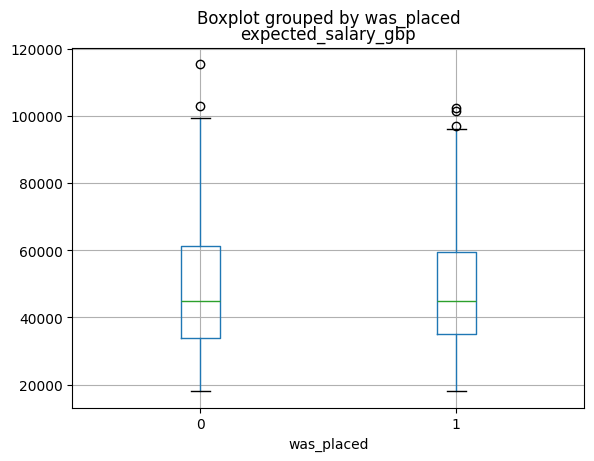

In [11]:
# ==== BIVARIATE ANALYSIS ==== # relationships between features and your target

df.groupby('seniority_level')['was_placed'].mean()   # placement rate by seniority
df.groupby('remote_preference')['was_placed'].mean()
df.boxplot(column='expected_salary_gbp', by='was_placed')

==== Boxplot — Expected Salary by Placement ====

The boxplot compares expected_salary_gbp for unplaced (0) vs placed (1) candidates:

Both groups have nearly identical salary distributions — median around £40,000, Interquartile Range (IQR) roughly £30k–£60k

The unplaced group (0) has higher outliers reaching £120,000 — very high salary expectations may be contributing to non-placement

What this confirms: Expected salary alone does NOT predict placement well (matches the near-zero correlation of -0.018)


Both boxes look almost identical — same median, same spread, same range. This visually confirms what the correlation table said: expected_salary_gbp at -0.018 is essentially useless for predicting placement on its own.

In plain terms: whether a candidate expected £25k or £75k made almost no difference to whether they got placed. What actually drove placement was whether the offered salary matched their expectation — which is what salary_match_ratio captured (hence its near-perfect 0.99 correlation, though that's leakage as explained earlier).


One Practical Takeaway
For a recruiter, this boxplot is telling you: don't screen candidates out based on salary expectations alone — the data shows it's not a reliable predictor of whether a placement will happen.



In [12]:
# ==== CORRELATION ANALYSIS ==== #numeric features only 

df.select_dtypes(include='number').corr()['was_placed'].sort_values()

days_since_registration     -0.055178
english_proficiency         -0.032953
expected_salary_gbp         -0.018073
years_of_experience         -0.012325
candidate_id                 0.028752
assessment_score             0.054348
availability_notice_days     0.061824
time_to_hire_days            0.791113
offered_salary_gbp           0.793661
client_satisfaction_score    0.809607
interview_rounds             0.825886
salary_gap                   0.894659
salary_match_ratio           0.991650
was_placed                   1.000000
placement_id                      NaN
placement_fee_gbp                 NaN
estimated_fee_value_gbp           NaN
performance_rating                NaN
skills_count                      NaN
interview_efficiency              NaN
Name: was_placed, dtype: float64